In [2]:
import numpy as np
import matplotlib.pyplot as plt
import example1

In [24]:
def func(linear_transform, cov, eps=1e-6):
    """
    Quadratic approximation to mutual information of data with 
    covariance cov linearly transformed by linear_transform.

    linear_transform: (n, n) float32
    cov: (n, n) float32 covariance of data
    """
    linear_transform = np.asarray(linear_transform, dtype=np.float32)
    cov = np.asarray(cov, dtype=np.float32)

    Sigma = linear_transform @ cov @ linear_transform.T
    Sigma.flat[:: Sigma.shape[0] + 1] += eps
    diag = np.diag(Sigma)
    inv_sqrt = 1.0 / np.sqrt(diag)

    R = (Sigma * inv_sqrt[:, None]) * inv_sqrt[None, :]

    diff = R - np.eye(R.shape[0], dtype=np.float32)
    return 0.5 * np.sum(diff * diff, dtype=np.float32)

# ------------------------------------------------------------
# Quadratic approximation:
#   sum_{i<j} Sigma_ij^2 / (Sigma_ii Sigma_jj)
# ------------------------------------------------------------
def approx_objective(Sigma):
    return func(np.eye(Sigma.shape[0], dtype=np.float32), Sigma)


def grad(linear_transform, cov, eps=1e-6):
    """
    Closed-form gradient of quadratic total correlation
    """
    linear_transform = np.asarray(linear_transform, dtype=np.float32)
    cov = np.asarray(cov, dtype=np.float32)

    linear_transform_cov = linear_transform @ cov
    Sigma = linear_transform_cov @ linear_transform.T
    Sigma.flat[:: Sigma.shape[0] + 1] += eps

    diag = np.diag(Sigma)
    inv_diag = 1.0 / diag
    inv_sqrt = 1.0 / np.sqrt(diag)

    # R ∘ R
    Sigma_sq = Sigma * Sigma
    G = Sigma_sq * (inv_diag[:, None] * inv_diag[None, :])

    # (R ∘ R - I)
    G.flat[:: G.shape[0] + 1] -= 1.0

    # D_Sigma^{-1} (R ∘ R - I)
    G *= inv_diag[:, None]

    return (2.0 * G @ linear_transform_cov).astype(np.float32)




Sample covariance:
[[0.99083077 0.31055671 0.27781867 0.27032554 0.30177598]
 [0.31055671 1.00858227 0.30872517 0.29362271 0.28867   ]
 [0.27781867 0.30872517 0.9959498  0.2789324  0.30010524]
 [0.27032554 0.29362271 0.2789324  0.9559123  0.2860151 ]
 [0.30177598 0.28867    0.30010524 0.2860151  0.9958687 ]]

Exact objective:
  -log(det(Sigma) / prod(diag)) = 0.6200026579450723

Quadratic approximation:
  sum rho_ij^2 = 0.8699000477790833


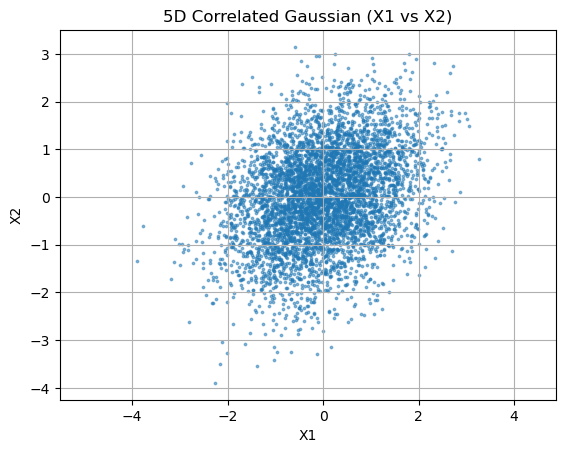

In [17]:
example1.plot_example(approx_objective, N=5, T=5000, rho=0.3)

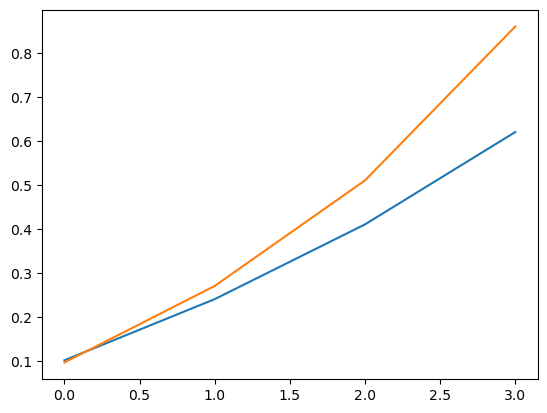

In [19]:
plt.plot([0.101, 0.24, 0.41, 0.62])
plt.plot([0.096, 0.27, 0.51, 0.86])

In [ ]:
def func(linear_transform, cov, eps=1e-6):
    """
    Quadratic approximation to mutual information of data with 
    covariance cov linearly transformed by linear_transform.

    linear_transform: (n, n) float32
    cov: (n, n) float32 covariance of data
    """
    linear_transform = np.asarray(linear_transform, dtype=np.float32)
    cov = np.asarray(cov, dtype=np.float32)

    Sigma = linear_transform @ cov @ linear_transform.T
    Sigma.flat[:: Sigma.shape[0] + 1] += eps
    diag = np.diag(Sigma)
    inv_sqrt = 1.0 / np.sqrt(diag)

    R = (Sigma * inv_sqrt[:, None]) * inv_sqrt[None, :]

    diff = R - np.eye(R.shape[0], dtype=np.float32)
    return 0.5 * np.sum(diff * diff, dtype=np.float32)



def grad(M, C, eps=1e-6):
    # 1. Forward pass
    MC = M @ C
    Sigma = MC @ M.T
    # Add epsilon to diagonal for stability
    Sigma.flat[::Sigma.shape[0] + 1] += eps
    
    d = np.diag(Sigma)
    Dm12 = np.diag(1.0 / np.sqrt(d))
    Dinv = np.diag(1.0 / d)
    
    R = Dm12 @ Sigma @ Dm12
    E = R - np.eye(R.shape[0], dtype=np.float32)

    # 2. Gradient w.r.t Sigma
    # Term 1: D^-1/2 * E * D^-1/2
    term1 = Dm12 @ E @ Dm12
    
    # Term 2: diag(D^-1 * E * R)
    # We only need the diagonal of (D^-1 @ E @ R)
    diag_term = np.diag(np.diag(Dinv @ E @ R))
    
    dLdSigma = term1 - diag_term

    # 3. Gradient w.r.t M
    return (2.0 * dLdSigma @ MC).astype(np.float32)



def gradient_descent(
    M,
    C,
    max_iter=200,
    alpha0=1.0,
    tau=0.5,
    c=1e-4,
    eps=1e-6,
    tol=1e-6,
):
    """
    Gradient descent with Armijo backtracking line search
    """

    M = np.asarray(M, dtype=np.float32)

    # Row normalization (fix scale ambiguity)
    M /= np.linalg.norm(M, axis=1, keepdims=True)


    f = func(M, C, eps)
    g = grad(M, C, eps)
    norm_g0 = np.linalg.norm(g)

    for it in range(max_iter):

        norm_g = np.linalg.norm(g)
        if norm_g < tol * norm_g0:
            break

        # Descent direction
        P = -g

        # Armijo RHS constant
        descent = c * np.sum(g * P)

        alpha = alpha0

        while True:
            M_trial = M + alpha * P
            f_trial= func(M_trial, C, eps)

            if f_trial <= f + alpha * descent:
                break

            alpha *= tau
            if alpha < 1e-8:
                break

        # Accept step
        M = M_trial

        # Row normalization (fix scale ambiguity)
        #M /= np.linalg.norm(M, axis=1, keepdims=True)

        f = func(M, C, eps)
        g = grad(M, C, eps)
        if it % 2 == 0:
            print(it, f)

    return M


In [84]:
cov = np.array([
    [1.0, 0.8, 0.5, 0.2],
    [0.8, 1.0, 0.3, 0.1],
    [0.5, 0.3, 1.0, 0.4],
    [0.2, 0.1, 0.4, 1.0],
])
M0 = np.eye(cov.shape[0], dtype=np.float32)
M = gradient_descent(M0, cov, max_iter=100)
#print(M.T @ cov @ M)

0 0.84327232837677
2 0.11440061032772064
4 0.04007197916507721
6 0.02558188885450363
8 0.001485767774283886
10 0.00010184631537413225
12 6.300446329987608e-06
14 5.513936116585683e-07
16 3.4677729132681634e-08
18 1.5676373976702962e-08
20 6.049027945209673e-10
22 1.0011787926478277e-10
24 4.650472715250764e-12


In [85]:
import numpy as np
from scipy.spatial import ConvexHull

def get_extreme_columns(D):
    """
    Reduces D to the minimal subset of columns (extreme rays) 
    that define the same positive cone.
    """
    # Normalize columns to the unit sphere to treat the cone as a hull problem
    D_norm = D / (np.linalg.norm(D, axis=0) + 1e-12)
    
    # ConvexHull identifies the points that form the 'outer' boundary
    hull = ConvexHull(D_norm.T)
    return D[:, hull.vertices]

def func_barrier(M, C, D_reduced, mu, eps=1e-6):
    f_orig = func(M, C, eps)
    MD = M @ D_reduced
    
    # Hard barrier for line search
    if np.any(MD <= 0):
        return 1e15
        
    penalty = -mu * np.sum(np.log(MD + 1e-15))
    return f_orig + penalty

def grad_barrier(M, C, D_reduced, mu, eps=1e-6):
    g_orig = grad(M, C, eps)
    
    # Barrier gradient: -mu * (1/MD) @ D.T
    MD = M @ D_reduced
    g_penalty = -mu * (1.0 / (MD + 1e-12)) @ D_reduced.T
    
    return g_orig + g_penalty

def gradient_descent_loop(
    M,
    C,
    D_reduced,
    mu,
    max_iter=200,
    alpha0=1.0,
    tau=0.5,
    c=1e-4,
    eps=1e-6,
    tol=1e-6,
):
    """
    Gradient descent with Armijo backtracking line search
    """

    M = np.asarray(M, dtype=np.float32)

    # Row normalization (fix scale ambiguity)
    M /= np.linalg.norm(M, axis=1, keepdims=True)


    f = func_barrier(M, C, D_reduced, mu, eps)
    g = grad_barrier(M, C, D_reduced, mu, eps)
    norm_g0 = np.linalg.norm(g)

    for it in range(max_iter):

        norm_g = np.linalg.norm(g)
        if norm_g < tol * norm_g0:
            break

        # Descent direction
        P = -g

        # Armijo RHS constant
        descent = c * np.sum(g * P)

        alpha = alpha0

        while True:
            M_trial = M + alpha * P
            f_trial= func_barrier(M_trial, C, D_reduced, mu, eps)

            if f_trial <= f + alpha * descent:
                break

            alpha *= tau
            if alpha < 1e-8:
                break

        # Accept step
        M = M_trial

        # Row normalization (fix scale ambiguity)
        #M /= np.linalg.norm(M, axis=1, keepdims=True)

        f = func_barrier(M, C, D_reduced, mu, eps)
        g = grad_barrier(M, C, D_reduced, mu, eps)
        if it % 2 == 0:
            print(it, f)

    return M

def solve_with_barrier(M_init, C, D, mu_start=0.1, mu_end=1e-7, decay=0.1):
    # 1. Pre-process D to speed up every single iteration
    print(f"Original D columns: {D.shape[1]}")
    D_reduced = get_extreme_columns(D)
    print(f"Reduced D columns: {D_reduced.shape[1]}")

    M = M_init.copy()
    mu = mu_start
    
    # 2. Sequential Unconstrained Minimization
    while mu >= mu_end:
        # Pass the reduced D and current mu into your gradient descent logic
        M = gradient_descent_loop(M, C, D_reduced, mu)
        mu *= decay
        
    return M

In [73]:
np.round(M @ cov @ M.T,decimals=3)

array([[ 0.517,  0.   ,  0.   , -0.   ],
       [ 0.   ,  2.025, -0.   ,  0.   ],
       [ 0.   , -0.   ,  3.429, -0.   ],
       [-0.   ,  0.   , -0.   ,  2.906]])